**Regularization and Advanced Classification**
-
* **Name:** Enrico Miguel Veloso
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 3/10/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
----
* **Implementation of models and concepts:** Regularization and Advanced Classification
* **Dataset:** Adult Income (Census 1994)
* **Dataset Description:** The Adult Income dataset contains demographic and employment information for 32,561 individuals from the 1994 U.S. Census.
* **Objective:** In this assessment, you will explore how regularization techniques (Lasso, Ridge, Elastic Net) improve linear models, compare them with powerful ensemble methods, and develop your ability to select and justify the best model for a real-world classification task.
----

In [81]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import statsmodels.formula.api as smf
import random
import time
import warnings
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve, \
    RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
warnings.filterwarnings('ignore')

#Set plotting style:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#Set seed:
random.seed(16)

**1. Data Preparation and Quick EDA**
-

In [82]:
#Load the dataset:
df = fetch_openml('adult', version = 2, as_frame = True)
df = df.frame
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [83]:
#Check dataframe shape: (Source Code: from assessment 6)
df_shape = df.shape

In [84]:
print("Total number of rows:", df_shape[0])
print("Total number of columns:", df_shape[1])

Total number of rows: 48842
Total number of columns: 15


In [85]:
#Dataset descriptive statistics: (Source Code: from assessment 6)
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [86]:
#Check for null values: (Source Code: from assessment 6)
num_null_col = df.isnull().sum()
num_null_row = df.isnull().any(axis=1).sum()
num_not_null_row = df.notnull().all(axis=1).sum()

In [87]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 3620


In [88]:
#Handling missing values: (Source Code: from assessment 6)
df_clean = df.dropna()
num_null_col = df_clean.isnull().sum()
num_null_row = df_clean.isnull().any(axis=1).sum()
num_not_null_row = df_clean.notnull().all(axis=1).sum()
total_rows = df.shape[0]
remaining_rows = df_clean.shape[0]
data_loss_percent = ((total_rows - remaining_rows) / total_rows) * 100

In [89]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)
print("Data loss after dropping all rows with null values:", f"{data_loss_percent:.2f}","%")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 0
Data loss after dropping all rows with null values: 7.41 %


In [90]:
#Create target variable: (Source Code: from assessment 6)
df_clean['high_income'] = (df_clean['class'] == '>50K').astype(int)
df_clean = df_clean.drop('class', axis = 1)
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,high_income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [91]:
#Target variable distribution in counts and percentages: (Source Code: from assessment 6)
counts = df_clean['high_income'].value_counts().sort_index()
percentages = df_clean['high_income'].value_counts(normalize=True).sort_index() * 100

In [92]:
print("=" * 40)
print("Counts:", counts)
print("=" * 40)
print("Percentages:", percentages)

Counts: high_income
0    34014
1    11208
Name: count, dtype: int64
Percentages: high_income
0    75.215603
1    24.784397
Name: proportion, dtype: float64


In [93]:
#Group all columns that are categorical: (Source Code: from assessment 6)
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = " | ".join(categorical_cols)

In [94]:
print("Categorical columns:", categorical_cols)

Categorical columns: workclass | education | marital-status | occupation | relationship | race | sex | native-country


In [95]:
#Convert categorical to dummy variables: (Source Code: from assessment 6)
dum_WC = pd.get_dummies(df_clean['workclass'], prefix = "WC", drop_first = True).astype(int)
dum_EDUC = pd.get_dummies(df_clean['education'], prefix = "EDUC", drop_first = True).astype(int)
dum_MS = pd.get_dummies(df_clean['marital-status'], prefix = "MS", drop_first = True).astype(int)
dum_OCC = pd.get_dummies(df_clean['occupation'], prefix = "OCC", drop_first = True).astype(int)
dum_REL = pd.get_dummies(df_clean['relationship'], prefix = "REL", drop_first = True).astype(int)
dum_RCE = pd.get_dummies(df_clean['race'], prefix = "RCE", drop_first = True).astype(int)
dum_SX = pd.get_dummies(df_clean['sex'], prefix = "SX", drop_first = True).astype(int)
dum_NC = pd.get_dummies(df_clean['native-country'], prefix = "NC", drop_first = True).astype(int)
df_clean = pd.concat([df_clean, dum_WC, dum_EDUC, dum_MS, dum_OCC, dum_REL, dum_RCE, dum_SX, dum_NC], axis = 1)
df_clean = df_clean.dropna()
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,NC_Portugal,NC_Puerto-Rico,NC_Scotland,NC_South,NC_Taiwan,NC_Thailand,NC_Trinadad&Tobago,NC_United-States,NC_Vietnam,NC_Yugoslavia
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,0,0,0,0,0,0,1,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,0,0,0,0,0,0,1,0,0
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,...,0,0,0,0,0,0,0,1,0,0


In [96]:
print("Check if there are null values after creation of dummy variables")
print("=" * 64)
print(df_clean.isnull().sum())

Check if there are null values after creation of dummy variables
age                   0
workclass             0
fnlwgt                0
education             0
education-num         0
                     ..
NC_Thailand           0
NC_Trinadad&Tobago    0
NC_United-States      0
NC_Vietnam            0
NC_Yugoslavia         0
Length: 106, dtype: int64


In [97]:
#Drop non-numerical features or columns: (Source Code: from assessment 6)
df_clean = df_clean.select_dtypes(include = ['number'])
numerical_cols = " | ".join(df_clean.columns.tolist())
num_cols = len(df_clean.columns.tolist())

In [98]:
print("Total number of columns or features:", num_cols)
print("=" * 60)
print(numerical_cols)

Total number of columns or features: 98
age | fnlwgt | education-num | capital-gain | capital-loss | hours-per-week | high_income | WC_Local-gov | WC_Never-worked | WC_Private | WC_Self-emp-inc | WC_Self-emp-not-inc | WC_State-gov | WC_Without-pay | EDUC_11th | EDUC_12th | EDUC_1st-4th | EDUC_5th-6th | EDUC_7th-8th | EDUC_9th | EDUC_Assoc-acdm | EDUC_Assoc-voc | EDUC_Bachelors | EDUC_Doctorate | EDUC_HS-grad | EDUC_Masters | EDUC_Preschool | EDUC_Prof-school | EDUC_Some-college | MS_Married-AF-spouse | MS_Married-civ-spouse | MS_Married-spouse-absent | MS_Never-married | MS_Separated | MS_Widowed | OCC_Armed-Forces | OCC_Craft-repair | OCC_Exec-managerial | OCC_Farming-fishing | OCC_Handlers-cleaners | OCC_Machine-op-inspct | OCC_Other-service | OCC_Priv-house-serv | OCC_Prof-specialty | OCC_Protective-serv | OCC_Sales | OCC_Tech-support | OCC_Transport-moving | REL_Not-in-family | REL_Other-relative | REL_Own-child | REL_Unmarried | REL_Wife | RCE_Asian-Pac-Islander | RCE_Black | RCE_

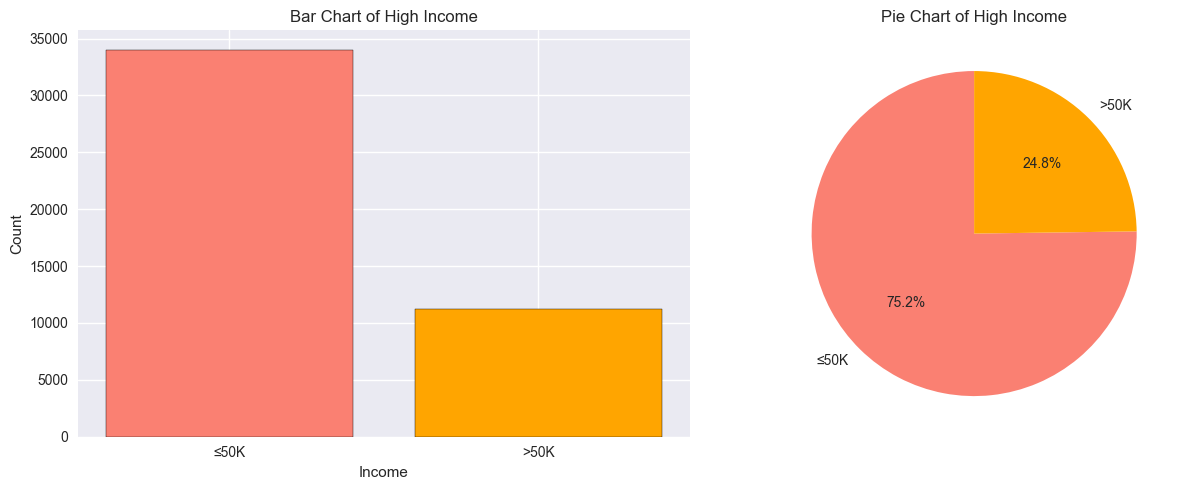

In [99]:
#Visualizations showing the distribution of the target variable: (Source Code: from assessment 6)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Bar chart (counts): (Source Code: from assessment 6)
counts = df_clean['high_income'].value_counts().sort_index()
axes[0].bar(['≤50K', '>50K'], counts, color=['salmon', 'orange'], edgecolor='black')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].set_title('Bar Chart of High Income')

#Pie chart (percentages): (Source Code: from assessment 6)
df_clean['high_income'].value_counts().plot.pie(autopct='%1.1f%%', labels=['≤50K', '>50K'], colors=['salmon', 'orange'], ax=axes[1], startangle=90)
axes[1].set_title('Pie Chart of High Income')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

---
* This is the distribution of values from the target variable "high_income".
* The majority of users are below or equal to the 50k marked which label's them as low incoming individuals.
* We used piechart and bar graph to better visualize the difference in number.
* There is a class imbalance in terms of individuals who have high and low income.
---

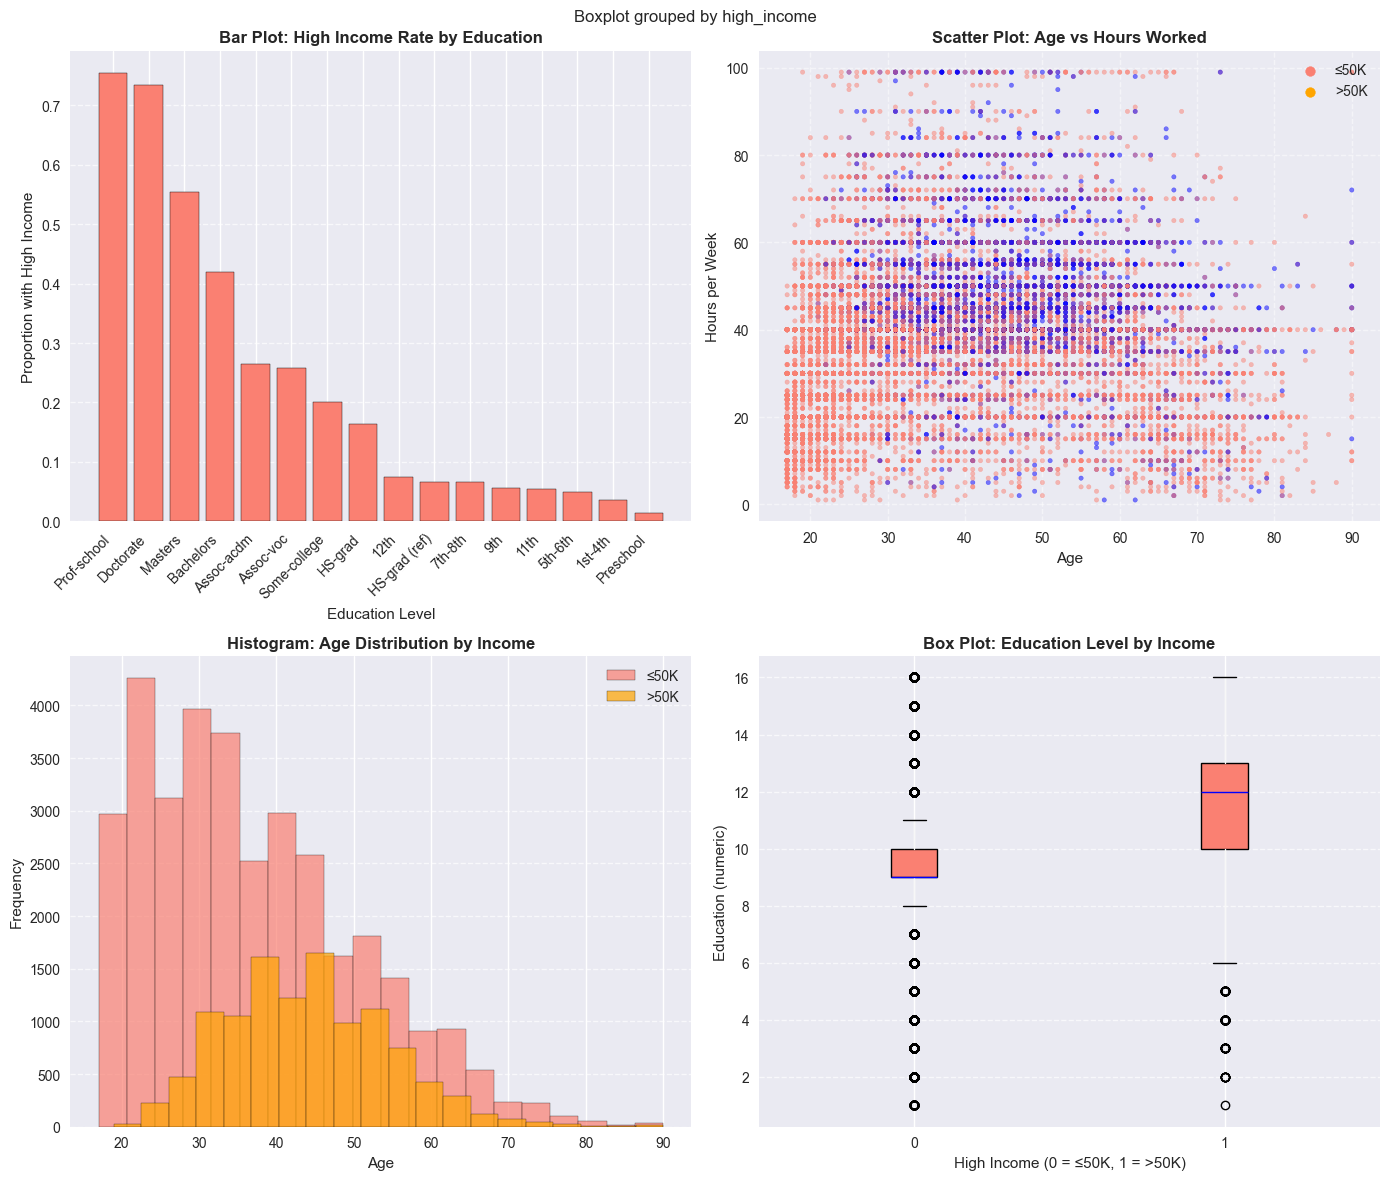

In [100]:
#Generate at least 3 informative plots exploring relationships between features and target: (Source Code: from assessment 6)

#Prepare data for education bar plot (using dummy columns from your encoding): (Source Code: from assessment 6)
educ_dummies = [col for col in df_clean.columns if col.startswith('EDUC_')]
educ_means = []
for col in educ_dummies:
    mean_val = df_clean.loc[df_clean[col] == 1, 'high_income'].mean()
    cat_name = col.replace('EDUC_', '')
    educ_means.append((cat_name, mean_val))

#Reference category (all dummies = 0) – label it appropriately: (Source Code: from assessment 6)
ref_mask = (df_clean[educ_dummies] == 0).all(axis=1)
ref_mean = df_clean.loc[ref_mask, 'high_income'].mean()
educ_means.append(('HS-grad (ref)', ref_mean))
educ_df = pd.DataFrame(educ_means, columns=['Education', 'Proportion_High_Income'])
educ_df = educ_df.sort_values('Proportion_High_Income', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Relationships Between Features and Income', fontsize=16, fontweight='bold')

#Bar plot: Education vs High Income Rate: (Source Code: from assessment 6)
ax = axes[0, 0]
bars = ax.bar(educ_df['Education'], educ_df['Proportion_High_Income'], color='salmon', edgecolor='black')
ax.set_xlabel('Education Level')
ax.set_ylabel('Proportion with High Income')
ax.set_title('Bar Plot: High Income Rate by Education', fontweight='bold')
ax.set_xticklabels(educ_df['Education'], rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Scatter plot: Age vs Hours per Week: (Source Code: from assessment 6)
ax = axes[0, 1]
colors = df_clean['high_income'].map({0: 'salmon', 1: 'blue'})
ax.scatter(df_clean['age'], df_clean['hours-per-week'], c=colors, alpha=0.5, s=10)
ax.set_xlabel('Age')
ax.set_ylabel('Hours per Week')
ax.set_title('Scatter Plot: Age vs Hours Worked', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.scatter([], [], color='salmon', label='≤50K')
ax.scatter([], [], color='orange', label='>50K')
ax.legend()

#Histogram: Age distribution by income group: (Source Code: from assessment 6)
ax = axes[1, 0]
df_clean[df_clean['high_income'] == 0]['age'].hist(ax=ax, bins=20, alpha=0.7, label='≤50K', color='salmon', edgecolor='black')
df_clean[df_clean['high_income'] == 1]['age'].hist(ax=ax, bins=20, alpha=0.7, label='>50K', color='orange', edgecolor='black')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Histogram: Age Distribution by Income', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Box plot: Education-num by income group: (Source Code: from assessment 6)
ax = axes[1, 1]
df_clean.boxplot(column='education-num', by='high_income', ax=ax, patch_artist=True, boxprops=dict(facecolor='salmon'), medianprops=dict(color='blue'))
ax.set_title('Box Plot: Education Level by Income', fontweight='bold')
ax.set_xlabel('High Income (0 = ≤50K, 1 = >50K)')
ax.set_ylabel('Education (numeric)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
* **Created 4 visualizations about the following:**
  * **Bar Plot:** which depicts high income rate by education.
  * **Scatter Plot:** depicts age vs hour worked.
  * **Histogram:** shows the distribution age by income.
  * **Box Plot:** which emphasizes education level by income.
---

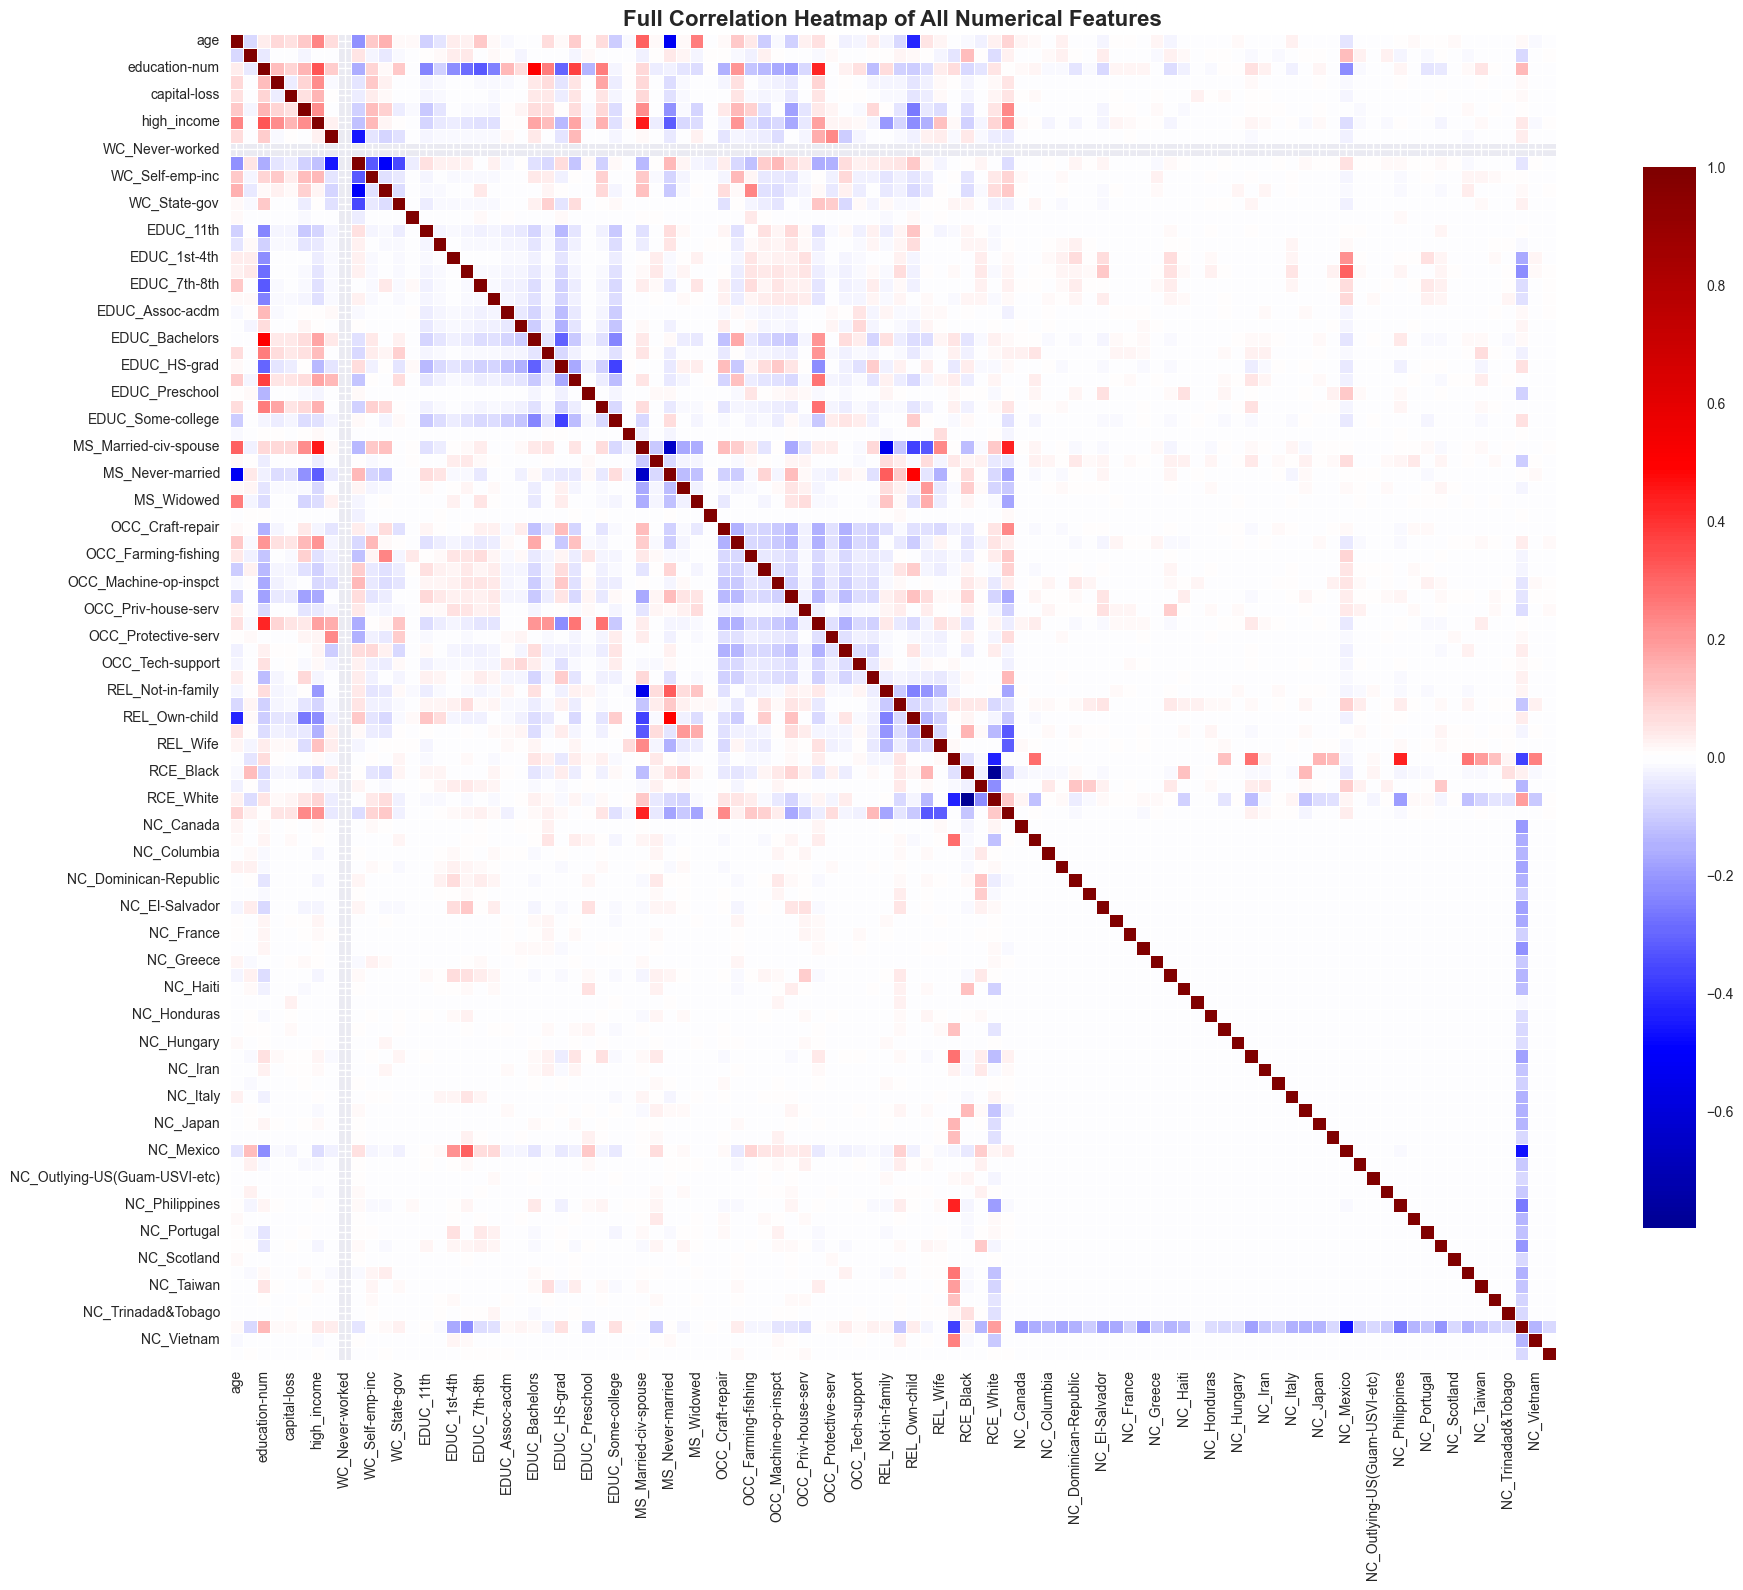

In [101]:
#Correlation heatmap for numerical features: (Source Code: from assessment 6)
plt.figure(figsize=(20, 16))
corr_full = df_clean.corr()
sns.heatmap(corr_full, annot=False, cmap='seismic', center=0,square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Full Correlation Heatmap of All Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

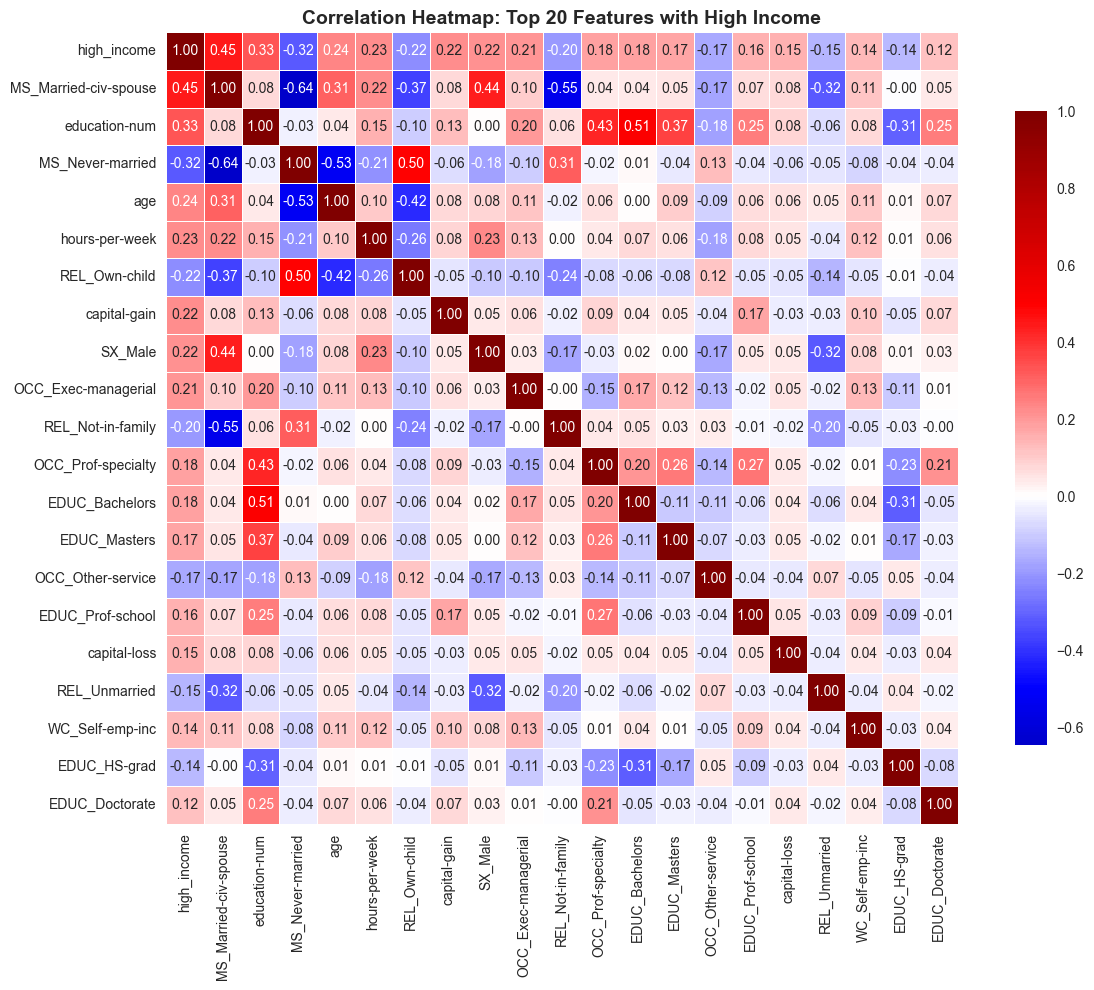

In [102]:
#Focused heatmap: top 20 features most correlated with high_income: (Source Code: from assessment 6)
corr_target = df_clean.corr()['high_income'].abs().sort_values(ascending=False)
top_features = corr_target.head(21).index
plt.figure(figsize=(13, 10))
sns.heatmap(df_clean[top_features].corr(), annot=True, fmt='.2f', cmap='seismic', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 20 Features with High Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**2. Train-Test Split without Feature Selection**
-

In [103]:
#Prepare your feature (X) and target variable (y) for Random Forest application of features selection: (Source Code: from assessment 6)
X = df_clean.drop('high_income', axis = 1)
y = df_clean['high_income']

In [104]:
#Split dataframe to test and train sets for Random Forest application: (Source Code: from assessment 6)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [105]:
#Standardize features: (Source Code: from assessment 6)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
print("Training set shape:")
print("=" * 40)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("=" * 40)
print("Testing set shape:")
print("=" * 40)
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training set shape:
X_train: (36177, 97)
y_train: (36177,)
Testing set shape:
X_test: (9045, 97)
y_test: (9045,)


In [107]:
print("Scaled training set shape:")
print("=" * 40)
print(f"X_train: {X_train_scaled.shape}")
print(f"y_train: {y_train.shape}")
print("=" * 40)
print("Scaled testing set shape:")
print("=" * 40)
print(f"X_test: {X_test_scaled.shape}")
print(f"y_test: {y_test.shape}")

Scaled training set shape:
X_train: (36177, 97)
y_train: (36177,)
Scaled testing set shape:
X_test: (9045, 97)
y_test: (9045,)


**3. Ten-Model Training and Implementation**
-

**1.) Linear Probability Model (LPM) - Baseline:**

In [108]:
#LPM baseline with no regularization: (Source Code: assisted and generated from DeepSeek)
lpm = LinearRegression()
lpm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**2.) Linear Probability Model (LPM) + Lasso:**

In [109]:
#LPM + Lasso (tune alphas with built-in CV): (Source Code: assisted and generated from DeepSeek)
lpm_lasso = LassoCV(cv = 5, random_state = 42)
lpm_lasso.fit(X_train_scaled, y_train)
best_alpha_lpm_lasso = lpm_lasso.alpha_

**3.) Linear Probability Model (LPM) + Ridge:**

In [110]:
#LPM + Ridge (tune alpha with built-in CV): (Source Code: assisted and generated from DeepSeek)
lpm_ridge = RidgeCV(cv = 5)
lpm_ridge.fit(X_train_scaled, y_train)
best_alpha_lpm_ridge = lpm_ridge.alpha_

**4.) Linear Probability Model (LPM) + Elastic Net:**

In [111]:
#LPM + Elastic Net (tune alpha and l1_ratio): (Source Code: assisted and generated from DeepSeek)
lpm_elastic = ElasticNetCV(cv = 5, l1_ratio = [0.25, 0.50, 0.75], random_state = 42)
lpm_elastic.fit(X_train_scaled, y_train)
best_alpha_lpm_elastic = lpm_elastic.alpha_
best_l1Ratio_lpm_elastic = lpm_elastic.l1_ratio_

**5.) Logistic Regression Model - Baseline:**

In [112]:
#Logistic Regression baseline with no regularization: (Source Code: assisted and generated from DeepSeek)
logrm = LogisticRegression(penalty = None)
logrm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

**6.) Logistic Regression Model + Lasso:**

In [113]:
#LogRM + Lasso(L1): (Source Code: assisted and generated from DeepSeek)
logrm_lasso = LogisticRegressionCV(cv = 5, penalty = 'l1', Cs = 10, random_state = 42, solver = 'liblinear')
logrm_lasso.fit(X_train_scaled, y_train)
best_C_logrm_lasso = logrm_lasso.C_

**7.) Logistic Regression Model + Ridge:**

In [114]:
#LogRM + Ridge(L2): (Source Code: assisted and generated from DeepSeek)
logrm_ridge = LogisticRegressionCV(cv = 5, penalty = 'l2', Cs= 10, random_state = 42)
logrm_ridge.fit(X_train_scaled, y_train)
best_C_logrm_ridge = logrm_ridge.C_

**8.) Logistic Regression Model + Elastic Net:**

In [115]:
#LogRM + Elastic Net: (Source Code: assisted and generated from DeepSeek)
logrm_elastic = LogisticRegressionCV(cv = 5, penalty = 'elasticnet', Cs = 10, random_state = 42, l1_ratios = [0.25, 0.50, 0.75], solver = 'saga')
logrm_elastic.fit(X_train_scaled, y_train)
best_C_logrm_elastic = logrm_elastic.C_
best_l1Ratio_logrm_elastic = logrm_elastic.l1_ratio_

**9.) Random Forest w/HPAT:**

In [116]:
#Random Forest hyperparameter auto tuning via GridSearch CV or RandomizedSeacrhCV: (Source Code: assisted and generated from DeepSeek)
rf_param_grid = {'n_estimators':[100, 200], 'max_depth':[10, 15], 'max_features':['sqrt', 'log']}
rf = RandomForestClassifier(random_state = 42, n_jobs = -1)
rf_grid_search = GridSearchCV(rf, rf_param_grid,  cv = 5, n_jobs = -1)
rf_grid_search.fit(X_train, y_train)
best_param_rf_grid_search = rf_grid_search.best_params_

**10.) Gradient Boost w/HPAT:**

In [117]:
#Gradient Boost hyperparmeter auto tuning via GridSearch or RandomizedSearchCV: (Source Code: assisted and generated from DeepSeek)
gboost_param_grid = {'n_estimators':[100, 200], 'max_depth':[10, 15], 'learning_rate':[0.1, 0.2]}
gboost = GradientBoostingClassifier(random_state = 42)
gboost_rand_search = RandomizedSearchCV(estimator = gboost, param_distributions = gboost_param_grid, cv = 5, random_state = 42, n_jobs = -1)
gboost_rand_search.fit(X_train, y_train)
best_param_gboost_rand_search = gboost_rand_search.best_params_

**11.) Training Accuracy for baseline and regularized models of Linear Probability Model (LPM):**

In [118]:
#Training baseline and regularized models: (Source Code: modified from assessment 6)
lpm_train_pred = (lpm.predict(X_train) > 0.5).astype(int)
lpm_lasso_train_pred = (lpm_lasso.predict(X_train_scaled) > 0.5).astype(int)
lpm_ridge_train_pred = (lpm_ridge.predict(X_train_scaled) > 0.5).astype(int)
lpm_elastic_train_pred = (lpm_elastic.predict(X_train_scaled) > 0.5).astype(int)

#Training accuracy of baseline and regularized models: (Source Code: modified from assessment 6)
lpm_train_acc = accuracy_score(y_train, lpm_train_pred)
lpm_lasso_train_acc = accuracy_score(y_train, lpm_lasso_train_pred)
lpm_ridge_train_acc = accuracy_score(y_train, lpm_ridge_train_pred)
lpm_elastic_train_acc = accuracy_score(y_train, lpm_elastic_train_pred)

In [119]:
print("TRAININNG ACCURACY OF LINEAR PROBABILITY MODELS (Baseline and Regularization)")
print("=" * 77)
print(f"Baseline:{lpm_train_acc:.4f}")
print(f"Lasso:{lpm_lasso_train_acc:.4f}")
print(f"Ridge:{lpm_ridge_train_acc:.4f}")
print(f"Elastic Net:{lpm_elastic_train_acc:.4f}")

TRAININNG ACCURACY OF LINEAR PROBABILITY MODELS (Baseline and Regularization)
Baseline:0.8385
Lasso:0.8387
Ridge:0.8386
Elastic Net:0.8387


**12.) Training Accuracy for baseline and regularized models of Logistic Regression Model:**

In [120]:
#Training baseline and regularized models: (Source Code: modified from assessment 6)
logrm_train_pred = logrm.predict(X_train)
logrm_lasso_train_pred = logrm_lasso.predict(X_train_scaled)
logrm_ridge_train_pred = logrm_ridge.predict(X_train_scaled)
logrm_elastic_train_pred = logrm_elastic.predict(X_train_scaled)

#Training accuracy of baseline and regularized models: (Source Code: modified from assessment 6)
logrm_train_acc = accuracy_score(y_train, logrm_train_pred)
logrm_lasso_train_acc = accuracy_score(y_train, logrm_lasso_train_pred)
logrm_ridge_train_acc = accuracy_score(y_train, logrm_ridge_train_pred)
logrm_elastic_train_acc = accuracy_score(y_train, logrm_elastic_train_pred)

In [121]:
print("TRAININNG ACCURACY OF LOGISTIC REGRESSION MODELS (Baseline and Regularization)")
print("=" * 78)
print(f"Baseline:{logrm_train_acc:.4f}")
print(f"Lasso:{logrm_lasso_train_acc:.4f}")
print(f"Ridge:{logrm_ridge_train_acc:.4f}")
print(f"Elastic Net:{logrm_elastic_train_acc:.4f}")

TRAININNG ACCURACY OF LOGISTIC REGRESSION MODELS (Baseline and Regularization)
Baseline:0.7815
Lasso:0.8505
Ridge:0.8497
Elastic Net:0.8499


**13.) Training Accuracy of Random Forest (HPAT via GridSearchCV):**

In [122]:
#Training Random Forest model: (Source Code: assisted and generated from DeepSeek)
rf_train_pred = rf_grid_search.predict(X_train)

In [123]:
#Training accuracy of Random Forest model: (Source Code: assisted and generated from DeepSeek)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

In [124]:
print("TRAININNG ACCURACY OF RANDOM FOREST MODEL WITH HPAT")
print("=" * 51)
print(f"Training Accuracy:{rf_train_acc:.4f}")

TRAININNG ACCURACY OF RANDOM FOREST MODEL WITH HPAT
Training Accuracy:0.8782


**14.) Training Accuracy of Gradient Boost (HPAT via RandomizedSearchCV):**

In [125]:
#Training Random Forest model: (Source Code: assisted and generated from DeepSeek)
gboost_train_pred = gboost_rand_search.predict(X_train)

In [126]:
#Training accuracy of Random Forest model: (Source Code: assisted and generated from DeepSeek)
gboost_train_acc = accuracy_score(y_train, gboost_train_pred)

In [127]:
print("TRAININNG ACCURACY OF GRADIENT BOOSTING MODEL WITH HPAT")
print("=" * 55)
print(f"Training Accuracy:{gboost_train_acc:.4f}")

TRAININNG ACCURACY OF GRADIENT BOOSTING MODEL WITH HPAT
Training Accuracy:0.9253


**15.) Display the best hyperparamters found (for models 2-10):**

In [128]:
print("BEST HYPERPARMETERS PER MODEL")
print("=" * 29)
print(f"LPM + Lasso (apha): {best_alpha_lpm_lasso:.4f}")
print(f"LPM + Ridge (alpha): {best_alpha_lpm_ridge:.4f}")
print(f"LPM + ElasticNet (alpha): {best_alpha_lpm_elastic:.4f}")
print(f"LPM + ElasticNet (l1_ratio): {best_l1Ratio_lpm_elastic:.4f}")
print(f"LogRM + Lasso (C): {best_C_logrm_lasso[0]:.4f}")
print(f"LogRM + Ridge (C): {best_C_logrm_ridge[0]:.4f}")
print(f"LogRM + ElasticNet (C): {best_C_logrm_elastic[0]:.4f}")
print(f"LogRM + ElasticNet (l1_ratio): {best_l1Ratio_logrm_elastic[0]:.4f}")
print(f"Random Forest best parameters: {best_param_rf_grid_search}")
print(f"Gradient Boost best parameters: {best_param_gboost_rand_search}")

BEST HYPERPARMETERS PER MODEL
LPM + Lasso (apha): 0.0002
LPM + Ridge (alpha): 10.0000
LPM + ElasticNet (alpha): 0.0003
LPM + ElasticNet (l1_ratio): 0.7500
LogRM + Lasso (C): 0.0464
LogRM + Ridge (C): 0.3594
LogRM + ElasticNet (C): 0.0464
LogRM + ElasticNet (l1_ratio): 0.5000
Random Forest best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200}
Gradient Boost best parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1}


**16.) A summary table at the end listing all 10 models, their training accuracy, and key hyperparameters:**

In [129]:
#Collect model names and corresponding accuracies and hyperparameters: (Source Code: assisted and generated from DeepSeek)
summary_data = {
    "Model": [
        "LPM – Baseline",
        "LPM + Lasso",
        "LPM + Ridge",
        "LPM + Elastic Net",
        "Logistic Regression – Baseline",
        "Logistic Regression + Lasso",
        "Logistic Regression + Ridge",
        "Logistic Regression + Elastic Net",
        "Random Forest (HPAT)",
        " Gradient Boosting (HPAT)"
    ],
    "Training Accuracy": [
        f"{lpm_train_acc:.4f}",
        f"{lpm_lasso_train_acc:.4f}",
        f"{lpm_ridge_train_acc:.4f}",
        f"{lpm_elastic_train_acc:.4f}",
        f"{logrm_train_acc:.4f}",
        f"{logrm_lasso_train_acc:.4f}",
        f"{logrm_ridge_train_acc:.4f}",
        f"{logrm_elastic_train_acc:.4f}",
        f"{rf_train_acc:.4f}",
        f"{gboost_train_acc:.4f}"
    ],
    "Key Hyperparameters": [
        "fit_intercept=True",
        f"α = {best_alpha_lpm_lasso:.4f}",
        f"α = {best_alpha_lpm_ridge:.1f}",
        f"α = {best_alpha_lpm_elastic:.4f}, "
        f"l1_ratio = {best_l1Ratio_lpm_elastic:.1f}",
        "penalty=None",
        f"C = {best_C_logrm_lasso[0]:.4f}, penalty='l1'",
        f"C = {best_C_logrm_ridge[0]:.4f}, penalty='l2'",
        f"C = {best_C_logrm_elastic[0]:.4f}, "
        f"l1_ratio = {best_l1Ratio_logrm_elastic[0]:.1f}",
        f"max_depth={best_param_rf_grid_search['max_depth']}, "
        f"max_features='{best_param_rf_grid_search['max_features']}', "
        f"n_estimators={best_param_rf_grid_search['n_estimators']}",
        f"learning_rate={best_param_gboost_rand_search['learning_rate']}, "
        f"max_depth={best_param_gboost_rand_search['max_depth']}, "
        f"n_estimators={best_param_gboost_rand_search['n_estimators']}"
    ]
}
summary_df = pd.DataFrame(summary_data)

In [130]:
print("=" * 106)
print(f"{'SUMMARY TABLE':^106}")
print("=" * 106)
print(summary_df.to_string(index=False))
print("=" * 106)

                                              SUMMARY TABLE                                               
                            Model Training Accuracy                                 Key Hyperparameters
                   LPM – Baseline            0.8385                                  fit_intercept=True
                      LPM + Lasso            0.8387                                          α = 0.0002
                      LPM + Ridge            0.8386                                            α = 10.0
                LPM + Elastic Net            0.8387                          α = 0.0003, l1_ratio = 0.8
   Logistic Regression – Baseline            0.7815                                        penalty=None
      Logistic Regression + Lasso            0.8505                            C = 0.0464, penalty='l1'
      Logistic Regression + Ridge            0.8497                            C = 0.3594, penalty='l2'
Logistic Regression + Elastic Net            0.8499          

**4. Feature Importance Analysis**
-

**1.) For Models 2, 3, 4, 6, 7, 8, 9, and 10, extract the top 7 most important features:**

In [131]:
#Get feature names from the training data: (Source Code: modified from assessment 6)
feature_names = X.columns.tolist()

In [132]:
#Helper function to extract top 7 features with their importance scores: (Source Code: assisted and generated from DeepSeek)
def get_top_features(coefs_or_importances, feature_names, n=7):
    abs_vals = np.abs(coefs_or_importances).flatten()
    top_indices = np.argsort(abs_vals)[-n:][::-1]
    return [feature_names[i] for i in top_indices]

In [133]:
#Collect top features for each model: (Source Code: assisted and generated from DeepSeek)
top_features = {
    "LPM + Lasso": get_top_features(lpm_lasso.coef_, feature_names),
    "LPM + Ridge": get_top_features(lpm_ridge.coef_, feature_names),
    "LPM + Elastic Net": get_top_features(lpm_elastic.coef_, feature_names),
    "Logistic + Lasso": get_top_features(logrm_lasso.coef_, feature_names),
    "Logistic + Ridge": get_top_features(logrm_ridge.coef_, feature_names),
    "Logistic + Elastic Net": get_top_features(logrm_elastic.coef_, feature_names),
    "Random Forest": get_top_features(rf_grid_search.best_estimator_.feature_importances_, feature_names),
    "Gradient Boosting": get_top_features(gboost_rand_search.best_estimator_.feature_importances_, feature_names)
}

In [134]:
#Create a DataFrame with ranks 1 to 7: (Source Code: assisted and generated from DeepSeek)
table_data = {model: features for model, features in top_features.items()}
rank_df = pd.DataFrame(table_data)
rank_df.index = [f"Rank {i+1}" for i in range(7)]
rank_df

,LPM + Lasso,LPM + Ridge,LPM + Elastic Net,Logistic + Lasso,Logistic + Ridge,Logistic + Elastic Net,Random Forest,Gradient Boosting
Rank 1,MS_Married-civ-spouse,REL_Not-in-family,MS_Married-civ-spouse,capital-gain,capital-gain,capital-gain,MS_Married-civ-spouse,MS_Married-civ-spouse
Rank 2,REL_Not-in-family,capital-gain,REL_Not-in-family,MS_Married-civ-spouse,MS_Married-civ-spouse,MS_Married-civ-spouse,capital-gain,education-num
Rank 3,education-num,MS_Married-civ-spouse,education-num,education-num,education-num,education-num,education-num,capital-gain
Rank 4,capital-gain,education-num,capital-gain,hours-per-week,SX_Male,hours-per-week,age,fnlwgt
Rank 5,OCC_Exec-managerial,REL_Own-child,OCC_Exec-managerial,SX_Male,hours-per-week,SX_Male,MS_Never-married,age
Rank 6,REL_Own-child,REL_Unmarried,REL_Own-child,REL_Own-child,age,REL_Own-child,hours-per-week,capital-loss
Rank 7,REL_Unmarried,OCC_Exec-managerial,REL_Unmarried,age,REL_Own-child,age,capital-loss,hours-per-week


---
**Analysis:**
* **Which features appear consistently in the top 7 across most models?**
  * education-num
  * MS_Married-civ-spouse
  * capital-gain
* **Are there any features that only appear important in certain models? What might explain this?**
  * **MS_Never-married:** Appears only in tree‑based models (Random Forest, Gradient Boosting). Tree models can capture complex interactions, whereas linear models treat it as a simple additive effect, diluting its importance.
  * **fnlwgt:** Appears only in Gradient Boosting. This feature is a demographic sampling weight, not a predictor of income. Its appearance is likely spurious – boosting may have used it to correct residual errors in one of its sequential trees.
  * **capital‑loss:** Appears in LPM + Ridge and the ensemble models, but not in Lasso or logistic models. Ridge shrinks correlated features together, allowing both to remain; Lasso tends to zero out one of them.
* **What does consistency (or inconsistency) across models tell us about the usefulness of a feature?**
  * High consistency indicates these are robust, generalizable signals – they capture true underlying patterns in the data that any well‑specified model will discover, regardless of its functional form.
  * Moderate inconsistency suggests the feature may participate in complex interactions; linear models cannot exploit those interactions, so they assign it lower importance, while tree‑based methods can and do.
  * Low or isolated appearance can point to noise or sampling artifacts – if a feature does not appear in most models, it should be treated with suspicion and investigated further.
  * Model‑specific features remind us that “importance” is model‑dependent. Relying on a single model’s feature ranking can be misleading; cross‑model consistency provides a more trustworthy view of what truly drives the target variable.
---

**5. Model Performance Evaluation**
-

**1.) Generate predictions for baseline and regularized models of Linear Probability Model (LPM):**

In [135]:
#Generate predictions for baseline and regularized models: (Source Code: modified from assessment 6)
lpm_test_pred = (lpm.predict(X_test) > 0.5).astype(int)
lpm_lasso_test_pred = (lpm_lasso.predict(X_test_scaled) > 0.5).astype(int)
lpm_ridge_test_pred = (lpm_ridge.predict(X_test_scaled) > 0.5).astype(int)
lpm_elastic_test_pred = (lpm_elastic.predict(X_test_scaled) > 0.5).astype(int)

**2.) Generate predictions for baseline and regularized models of Logistic Regression Model:**

In [136]:
#Generate predictions for baseline and regularized models: (Source Code: modified from assessment 6)
logrm_test_pred = (logrm.predict(X_test) > 0.5).astype(int)
logrm_lasso_test_pred = (logrm_lasso.predict(X_test_scaled) > 0.5).astype(int)
logrm_ridge_test_pred = (logrm_ridge.predict(X_test_scaled) > 0.5).astype(int)
logrm_elastic_test_pred = (logrm_elastic.predict(X_test_scaled) > 0.5).astype(int)

**3.) Gnerated predictions for Random Forest (HPAT via GridSearchCV):**

In [137]:
#Generate predictions Random Forest model: (Source Code: modified from assessment 6)
rf_test_pred = (rf_grid_search.predict(X_test) > 0.5).astype(int)

**4.) Gnerated predictions for Gradient Boosting (HPAT via RandomizedSearchSize):**

In [138]:
#Generate predictions Gradident Boost model: (Source Code: modified from assessment 6)
gboost_test_pred = (gboost_rand_search.predict(X_test) > 0.5).astype(int)

**5.) Classification Metrics: Linear Probaility Model (LPM):**

In [139]:
#Assingning all classification metrics for LPM baseline to a variable: (Source Code: modified from assessment 6)
acc_lpm = accuracy_score(y_test, lpm_test_pred)
pres_lpm = precision_score(y_test, lpm_test_pred, zero_division=0)
rec_lpm = recall_score(y_test, lpm_test_pred, zero_division=0)
f1_lpm = f1_score(y_test, lpm_test_pred, zero_division=0)
cm_lpm = confusion_matrix(y_test, lpm_test_pred)
tp_lpm, tn_lpm, fp_lpm, fn_lpm = cm_lpm.ravel()
spec_lpm = tn_lpm/(tn_lpm + fp_lpm)
te1_lpm = fp_lpm/(fp_lpm + tn_lpm)
te2_lpm = fn_lpm/(fn_lpm + tp_lpm)

**6.) Classification Metrics: LPM + Lasso:**

In [140]:
#Assingning all classification metrics for LPM + Lasso to a variable: (Source Code: modified from assessment 6)
acc_lpm_lasso = accuracy_score(y_test, lpm_lasso_test_pred)
pres_lpm_lasso = precision_score(y_test, lpm_lasso_test_pred, zero_division=0)
rec_lpm_lasso = recall_score(y_test, lpm_lasso_test_pred, zero_division=0)
f1_lpm_lasso = f1_score(y_test, lpm_lasso_test_pred, zero_division=0)
cm_lpm_lasso = confusion_matrix(y_test, lpm_lasso_test_pred)
tp_lpm_lasso, tn_lpm_lasso, fp_lpm_lasso, fn_lpm_lasso = cm_lpm_lasso.ravel()
spec_lpm_lasso = tn_lpm_lasso/(tn_lpm_lasso + fp_lpm_lasso)
te1_lpm_lasso = fp_lpm_lasso/(fp_lpm_lasso + tn_lpm_lasso)
te2_lpm_lasso = fn_lpm_lasso/(fn_lpm_lasso + tp_lpm_lasso)

**7.) Classification Metrics: LPM + Ridge:**

In [141]:
#Assingning all classification metrics for LPM + Ridge to a variable: (Source Code: modified from assessment 6)
acc_lpm_ridge = accuracy_score(y_test, lpm_ridge_test_pred)
pres_lpm_ridge = precision_score(y_test, lpm_ridge_test_pred, zero_division=0)
rec_lpm_ridge = recall_score(y_test, lpm_ridge_test_pred, zero_division=0)
f1_lpm_ridge = f1_score(y_test, lpm_ridge_test_pred, zero_division=0)
cm_lpm_ridge = confusion_matrix(y_test, lpm_ridge_test_pred)
tp_lpm_ridge, tn_lpm_ridge, fp_lpm_ridge, fn_lpm_ridge = cm_lpm_ridge.ravel()
spec_lpm_ridge = tn_lpm_ridge/(tn_lpm_ridge + fp_lpm_ridge)
te1_lpm_ridge = fp_lpm_ridge/(fp_lpm_ridge + tn_lpm_ridge)
te2_lpm_ridge = fn_lpm_ridge/(fn_lpm_ridge + tp_lpm_ridge)

**8.) Classification Metrics: LPM + Elastic net:**

In [142]:
#Assingning all classification metrics for LPM + Elasticnet to a variable: (Source Code: modified from assessment 6)
acc_lpm_elastic = accuracy_score(y_test, lpm_elastic_test_pred)
pres_lpm_elastic = precision_score(y_test, lpm_elastic_test_pred, zero_division=0)
rec_lpm_elastic = recall_score(y_test, lpm_elastic_test_pred, zero_division=0)
f1_lpm_elastic = f1_score(y_test, lpm_elastic_test_pred, zero_division=0)
cm_lpm_elastic = confusion_matrix(y_test, lpm_elastic_test_pred)
tp_lpm_elastic, tn_lpm_elastic, fp_lpm_elastic, fn_lpm_elastic = cm_lpm_elastic.ravel()
spec_lpm_elastic = tn_lpm_elastic/(tn_lpm_elastic + fp_lpm_elastic)
te1_lpm_elastic = fp_lpm_elastic/(fp_lpm_elastic + tn_lpm_elastic)
te2_lpm_elastic = fn_lpm_elastic/(fn_lpm_elastic + tp_lpm_elastic)

**9.) Classification Metrics: Logistic Regression Model:**

In [143]:
#Assingning all classification metrics for Logistic Regression baseline to a variable: (Source Code: modified from assessment 6)
acc_logrm = accuracy_score(y_test, logrm_test_pred)
pres_logrm = precision_score(y_test, logrm_test_pred, zero_division=0)
rec_logrm = recall_score(y_test, logrm_test_pred, zero_division=0)
f1_logrm = f1_score(y_test, logrm_test_pred, zero_division=0)
cm_logrm = confusion_matrix(y_test, logrm_test_pred)
tp_logrm, tn_logrm, fp_logrm, fn_logrm = cm_logrm.ravel()
spec_logrm = tn_logrm/(tn_logrm + fp_logrm)
te1_logrm = fp_logrm/(fp_logrm + tn_logrm)
te2_logrm = fn_logrm/(fn_logrm + tp_logrm)

**10.) Classification Metrics: LogRM + Lasso:**

In [144]:
#Assingning all classification metrics for Logistic Regression + Lasso to a variable: (Source Code: modified from assessment 6)
acc_logrm_lasso = accuracy_score(y_test, logrm_lasso_test_pred)
pres_logrm_lasso = precision_score(y_test, logrm_lasso_test_pred, zero_division=0)
rec_logrm_lasso = recall_score(y_test, logrm_lasso_test_pred, zero_division=0)
f1_logrm_lasso = f1_score(y_test, logrm_lasso_test_pred, zero_division=0)
cm_logrm_lasso = confusion_matrix(y_test, logrm_lasso_test_pred)
tp_logrm_lasso, tn_logrm_lasso, fp_logrm_lasso, fn_logrm_lasso = cm_logrm_lasso.ravel()
spec_logrm_lasso = tn_logrm_lasso/(tn_logrm_lasso + fp_logrm_lasso)
te1_logrm_lasso = fp_logrm_lasso/(fp_logrm_lasso + tn_logrm_lasso)
te2_logrm_lasso = fn_logrm_lasso/(fn_logrm_lasso + tp_logrm_lasso)

**11.) Classification Metrics: LogRM + Ridge:**

In [145]:
#Assingning all classification metrics for Logistic Regression + Ridge to a variable: (Source Code: modified from assessment 6)
acc_logrm_ridge = accuracy_score(y_test, logrm_ridge_test_pred)
pres_logrm_ridge = precision_score(y_test, logrm_ridge_test_pred, zero_division=0)
rec_logrm_ridge = recall_score(y_test, logrm_ridge_test_pred, zero_division=0)
f1_logrm_ridge = f1_score(y_test, logrm_ridge_test_pred, zero_division=0)
cm_logrm_ridge = confusion_matrix(y_test, logrm_ridge_test_pred)
tp_logrm_ridge, tn_logrm_ridge, fp_logrm_ridge, fn_logrm_ridge = cm_logrm_ridge.ravel()
spec_logrm_ridge = tn_logrm_ridge/(tn_logrm_ridge + fp_logrm_ridge)
te1_logrm_ridge = fp_logrm_ridge/(fp_logrm_ridge + tn_logrm_ridge)
te2_logrm_ridge = fn_logrm_ridge/(fn_logrm_ridge + tp_logrm_ridge)

**12.) Classification Metrics: LogRM + Elastic net:**

In [146]:
#Assingning all classification metrics for Logistic Regression + Elastic net to a variable: (Source Code: modified from assessment 6)
acc_logrm_elastic = accuracy_score(y_test, logrm_elastic_test_pred)
pres_logrm_elastic = precision_score(y_test, logrm_elastic_test_pred, zero_division=0)
rec_logrm_elastic = recall_score(y_test, logrm_elastic_test_pred, zero_division=0)
f1_logrm_elastic = f1_score(y_test, logrm_elastic_test_pred, zero_division=0)
cm_logrm_elastic = confusion_matrix(y_test, logrm_elastic_test_pred)
tp_logrm_elastic, tn_logrm_elastic, fp_logrm_elastic, fn_logrm_elactic = cm_logrm_elastic.ravel()
spec_logrm_elastic = tn_logrm_elastic/(tn_logrm_elastic + fp_logrm_elastic)
te1_logrm_elastic = fp_logrm_elastic/(fp_logrm_elastic + tn_logrm_elastic)
te2_logrm_elastic = fn_logrm_elactic/(fn_logrm_elactic + tp_logrm_elastic)

**13.) Classificatuon Metrics: Random Forest (HPAT):**

In [147]:
#Assingning all classification metrics for Random Forest (HPAT) net to a variable: (Source Code: modified from assessment 6)
acc_rf = accuracy_score(y_test, rf_test_pred)
pres_rf = precision_score(y_test, rf_test_pred, zero_division=0)
rec_rf = recall_score(y_test, rf_test_pred, zero_division=0)
f1_rf = f1_score(y_test, rf_test_pred, zero_division=0)
cm_rf = confusion_matrix(y_test, rf_test_pred)
tp_rf, tn_rf, fp_rf, fn_rf = cm_rf.ravel()
spec_rf = tn_rf/(tn_rf + fp_rf)
te1_rf = fp_rf/(fp_rf + tn_rf)
te2_rf = fn_rf/(fn_rf + tp_rf)

**14.) Classification Metrics: Gradient Boost (HPAT):**

In [148]:
#Assingning all classification metrics for Gradient Boost (HPAT) net to a variable: (Source Code: modified from assessment 6)
acc_gboost = accuracy_score(y_test, gboost_test_pred)
pres_gboost = precision_score(y_test, gboost_test_pred, zero_division=0)
rec_gboost = recall_score(y_test, gboost_test_pred, zero_division=0)
f1_gboost = f1_score(y_test, gboost_test_pred, zero_division=0)
cm_gboost = confusion_matrix(y_test, gboost_test_pred)
tp_gboost, tn_gboost, fp_gboost, fn_gboost = cm_gboost.ravel()
spec_gboost = tn_gboost/(tn_gboost + fp_gboost)
te1_gboost = fp_gboost/(fp_gboost + tn_gboost)
te2_gboost = fn_gboost/(fn_gboost + tp_gboost)

**15.) Confussion Matrix: Linear Probability Model (LPM):**

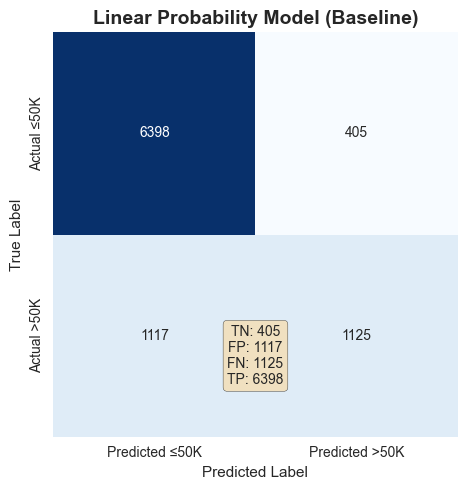

In [149]:
#Confusion matrix of LPM baseline model: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lpm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('Linear Probability Model (Baseline)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_lpm}\nFP: {fp_lpm}\nFN: {fn_lpm}\nTP: {tp_lpm}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**16.) Confusion Matrix: LPM + Lasso:**

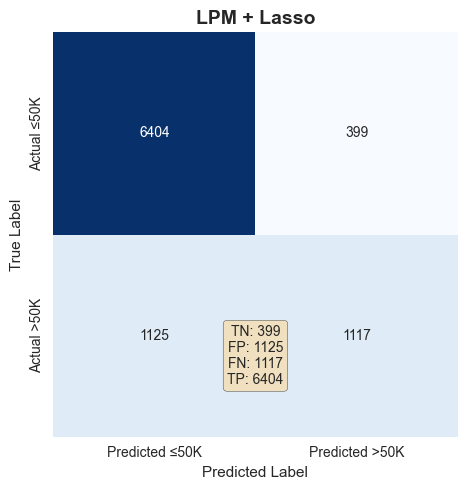

In [150]:
#Confusion matrix of LPM + Lasso: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lpm_lasso, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('LPM + Lasso', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_lpm_lasso}\nFP: {fp_lpm_lasso}\nFN: {fn_lpm_lasso}\nTP: {tp_lpm_lasso}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**17.) Confusion Matrix: LPM + Ridge:**

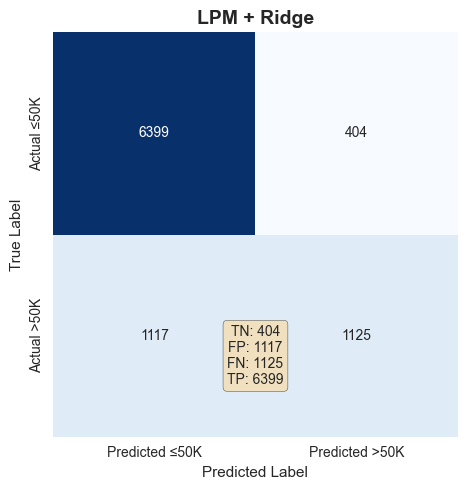

In [151]:
#Confusion matrix of LPM + Ridge: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lpm_ridge, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('LPM + Ridge', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_lpm_ridge}\nFP: {fp_lpm_ridge}\nFN: {fn_lpm_ridge}\nTP: {tp_lpm_ridge}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**18.) Confusion Matrix: LPM + Elastic net:**

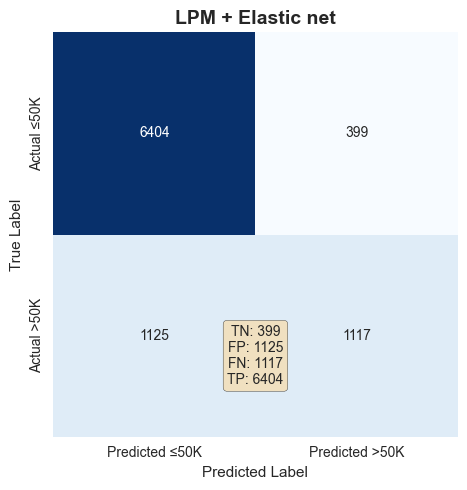

In [152]:
#Confusion matrix of LPM + Ridge: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lpm_elastic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('LPM + Elastic net', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_lpm_elastic}\nFP: {fp_lpm_elastic}\nFN: {fn_lpm_elastic}\nTP: {tp_lpm_elastic}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**19.) Confusion Matrix: Logistic Regression Model:**

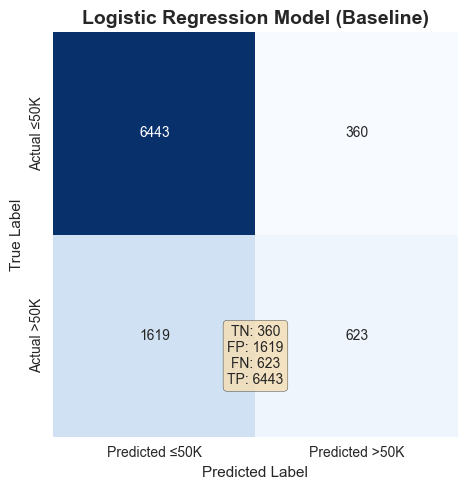

In [153]:
#Confusion matrix of Logistic Regression baseline model: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_logrm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('Logistic Regression Model (Baseline)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_logrm}\nFP: {fp_logrm}\nFN: {fn_logrm}\nTP: {tp_logrm}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**20.) Confusion Matrix: LogRM + Lasso:**

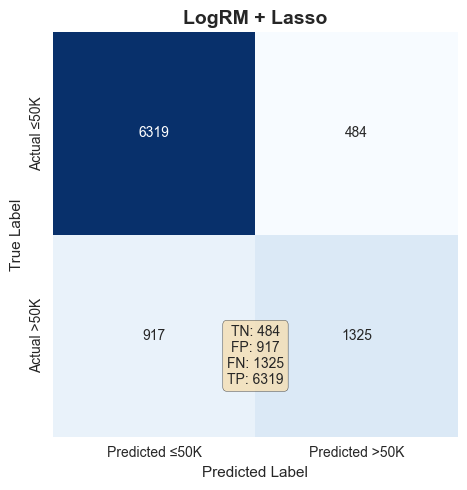

In [154]:
#Confusion matrix of LogRM + Lasso model: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_logrm_lasso, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('LogRM + Lasso', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_logrm_lasso}\nFP: {fp_logrm_lasso}\nFN: {fn_logrm_lasso}\nTP: {tp_logrm_lasso}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**21.) Confusion Matrix: LogRM + Ridge:**

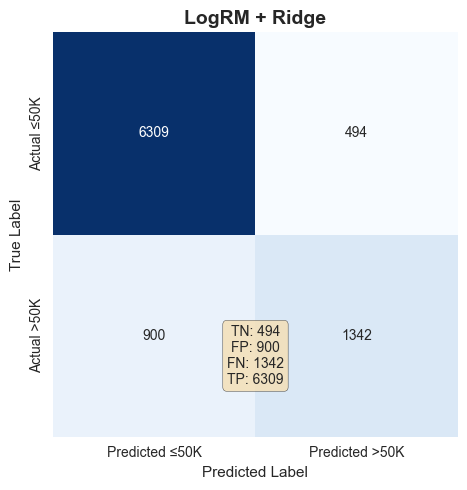

In [155]:
#Confusion matrix of LogRM + Ridge model: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_logrm_ridge, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('LogRM + Ridge', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_logrm_ridge}\nFP: {fp_logrm_ridge}\nFN: {fn_logrm_ridge}\nTP: {tp_logrm_ridge}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**22.) Confusion Matrix: LogRM + Elastic net:**

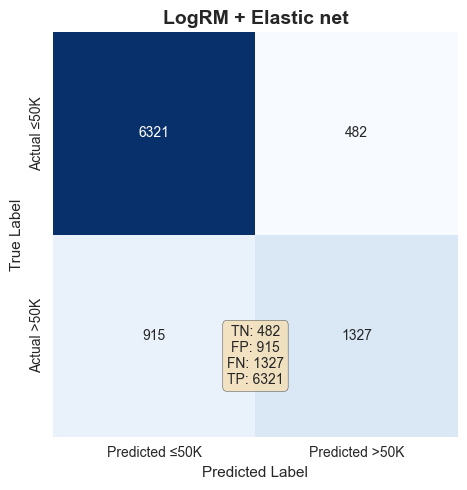

In [156]:
#Confusion matrix of LogRM + Elastic net model: (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_logrm_elastic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('LogRM + Elastic net', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_logrm_elastic}\nFP: {fp_logrm_elastic}\nFN: {fn_logrm_elactic}\nTP: {tp_logrm_elastic}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**23.) Confusion Matrix: Random Forest (HPAT):**

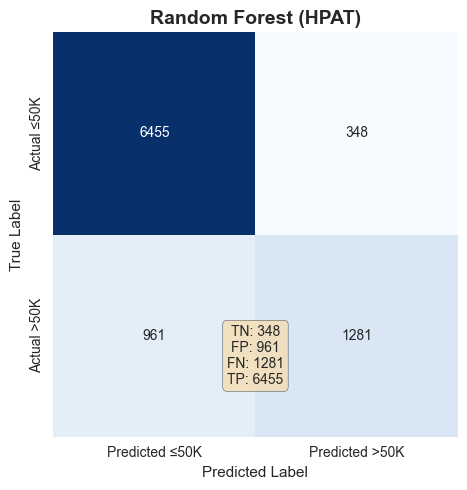

In [157]:
#Confusion matrix of Random Forest model (HPAT): (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('Random Forest (HPAT)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_rf}\nFP: {fp_rf}\nFN: {fn_rf}\nTP: {tp_rf}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**24.) Confusion Matrix: Gradient Boost (HPAT):**

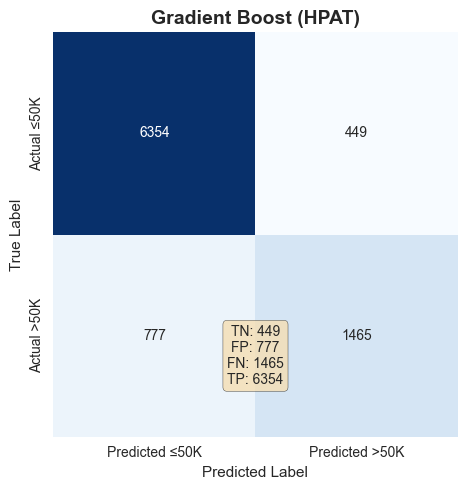

In [158]:
#Confusion matrix of Gradient Bosst model (HPAT): (Source Code: assisted and generated from DeepSeek)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gboost, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted ≤50K', 'Predicted >50K'],
            yticklabels=['Actual ≤50K', 'Actual >50K'],
            cbar=False, square=True)
plt.title('Gradient Boost (HPAT)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#Optional: Add a text box with TP/TN/FP/FN:
plt.text(0.5, 0.2,
         f'TN: {tn_gboost}\nFP: {fp_gboost}\nFN: {fn_gboost}\nTP: {tp_gboost}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

**25.) Create a single table comparing all 10 models:**

In [159]:
#Create a list of dictionaries for each model's metrics: (Source Code: modified from assessment 6)
metrics_data = [
    {
        "Model": "LPM (Baseline)",
        "Accuracy": acc_lpm,
        "Precision": pres_lpm,
        "Recall": rec_lpm,
        "F1-Score": f1_lpm,
        "Specificity": spec_lpm,
        "Type I Error": te1_lpm,
        "Type II Error": te2_lpm
    },
    {
        "Model": "LPM + Lasso",
        "Accuracy": acc_lpm_lasso,
        "Precision": pres_lpm_lasso,
        "Recall": rec_lpm_lasso,
        "F1-Score": f1_lpm_lasso,
        "Specificity": spec_lpm_lasso,
        "Type I Error": te1_lpm_lasso,
        "Type II Error": te2_lpm_lasso
    },
    {
        "Model": "LPM + Ridge",
        "Accuracy": acc_lpm_ridge,
        "Precision": pres_lpm_ridge,
        "Recall": rec_lpm_ridge,
        "F1-Score": f1_lpm_ridge,
        "Specificity": spec_lpm_ridge,
        "Type I Error": te1_lpm_ridge,
        "Type II Error": te2_lpm_ridge
    },
    {
        "Model": "LPM + Elastic net",
        "Accuracy": acc_lpm_elastic,
        "Precision": pres_lpm_elastic,
        "Recall": rec_lpm_elastic,
        "F1-Score": f1_lpm_elastic,
        "Specificity": spec_lpm_elastic,
        "Type I Error": te1_lpm_elastic,
        "Type II Error": te2_lpm_elastic
    },
    {
        "Model": "LogRM (Baseline)",
        "Accuracy": acc_logrm,
        "Precision": pres_logrm,
        "Recall": rec_logrm,
        "F1-Score": f1_logrm,
        "Specificity": spec_logrm,
        "Type I Error": te1_logrm,
        "Type II Error": te2_logrm
    },
    {
        "Model": "LogRM + Lasso",
        "Accuracy": acc_logrm_lasso,
        "Precision": pres_logrm_lasso,
        "Recall": rec_logrm_lasso,
        "F1-Score": f1_logrm_lasso,
        "Specificity": spec_logrm_lasso,
        "Type I Error": te1_logrm_lasso,
        "Type II Error": te2_logrm_lasso
    },
    {
        "Model": "LogRM + Ridge",
        "Accuracy": acc_logrm_ridge,
        "Precision": pres_logrm_ridge,
        "Recall": rec_logrm_ridge,
        "F1-Score": f1_logrm_ridge,
        "Specificity": spec_logrm_ridge,
        "Type I Error": te1_logrm_ridge,
        "Type II Error": te2_logrm_ridge
    },
    {
        "Model": "LogRM + Elastic net",
        "Accuracy": acc_logrm_elastic,
        "Precision": pres_logrm_elastic,
        "Recall": rec_logrm_elastic,
        "F1-Score": f1_logrm_elastic,
        "Specificity": spec_logrm_elastic,
        "Type I Error": te1_logrm_elastic,
        "Type II Error": te2_logrm_elastic
    },
    {
        "Model": "Random Forest (HPAT)",
        "Accuracy": acc_rf,
        "Precision": pres_rf,
        "Recall": rec_rf,
        "F1-Score": f1_rf,
        "Specificity": spec_rf,
        "Type I Error": te1_rf,
        "Type II Error": te2_rf
    },
    {
        "Model": "Gradient Boost (HPAT)",
        "Accuracy": acc_gboost,
        "Precision": pres_gboost,
        "Recall": rec_gboost,
        "F1-Score": f1_gboost,
        "Specificity": spec_gboost,
        "Type I Error": te1_gboost,
        "Type II Error": te2_gboost
    }
]

#Create DataFrame and format to 4 decimal places: (Source Code: assisted and generated from DeepSeek)
df_metrics = pd.DataFrame(metrics_data)
df_metrics = df_metrics.round(4)

In [160]:
print("=" * 105)
print("CLASSIFICATION METRICS COMPARISON")
print("=" * 105)
print(df_metrics.to_string(index=False))
print("=" * 105)

CLASSIFICATION METRICS COMPARISON
                Model  Accuracy  Precision  Recall  F1-Score  Specificity  Type I Error  Type II Error
       LPM (Baseline)    0.8317     0.7353  0.5018    0.5965       0.2661        0.7339         0.1495
          LPM + Lasso    0.8315     0.7368  0.4982    0.5945       0.2618        0.7382         0.1485
          LPM + Ridge    0.8318     0.7358  0.5018    0.5967       0.2656        0.7344         0.1495
    LPM + Elastic net    0.8315     0.7368  0.4982    0.5945       0.2618        0.7382         0.1485
     LogRM (Baseline)    0.7812     0.6338  0.2779    0.3864       0.1819        0.8181         0.0882
        LogRM + Lasso    0.8451     0.7324  0.5910    0.6542       0.3455        0.6545         0.1733
        LogRM + Ridge    0.8459     0.7309  0.5986    0.6582       0.3544        0.6456         0.1754
  LogRM + Elastic net    0.8456     0.7336  0.5919    0.6551       0.3450        0.6550         0.1735
 Random Forest (HPAT)    0.8553     0.7

---
**Regularization Impact on LPM - Model 1 vs. 2, 3, and 4:**
* **Compare the baseline model LPM (Model 1) againts the reqularized LPM versions (Model 2, 3, 4):**
  * **Did regularization Improve accuracy, precision, recall, or f1?**
    * **LPM (Baseline) Accuracy: 0.8317 = 83.17%**
        * **LPM + Lasso: 0.8315 = 83.15%** (the 0.0002 decrease difference in accuracy from the baseline model indicates that Lasso regularization had no impact and slightly failed to improve accuarcy performance).
        * **LPM + Ridge: 0.8318 = 83.18%** (the 0.0001 increase difference in accuracy from the baseline model indicates that Ridge regularization had a small impact and slightly improve accuracy performance).
        * **LPM + Elastic net: 0.8315 = 83.15%** (same output as LPM + Lasso which also delivered a poor performance in terms of improving accuracy performance of LPM).
    * **LPM (Baseline) Precision: 0.7353 = 73.53%**
        * **LPM + Lasso: 0.7368 = 73.68%** (the 0.0015 increase difference in precision from the baseline model indicates that Lasso regularization had an impact and improve precision performance).
        * **LPM + Ridge: 0.7358 = 73.58%** (the 0.0005 increase difference in precision from the baseline model indicates that Ridge regularization had a small impact and slighlty improve precision performance).
        * **LPM + Elastic net: 0.7368 = 73.68%** (same output as LPM + Lasso which also delivered an average to good performance in terms of improving precision performance of LPM).
    * **LPM (Baseline) Recall: 0.5018 = 50.18%**
        * **LPM + Lasso: 0.4982 = 49.82%** (the 0.0036 decrease difference in recall from the baseline model indicates that Lasso regularization had no impact and failed to improve recall performance).
        * **LPM + Ridge: 0.5018 = 50.18%** (same output as LPM (Baseline) which also indicates that Ridge regularization did no made an impact in terms of improving recall performance).
        * **LPM + Elastic net: 0.4982 = 49.82%** (same output as LPM + Lasso which also delivered a poor performance in terms of improving reacll performance of LPM).
    * **LPM (Baseline) F1-score: 0.5965 = 59.65%**
        * **LPM + Lasso: 0.5945 = 59.45%** (the 0.0020 decrease difference in f1-score from the baseline model indicates that Lasso regularization had no impact and falied to improve F1-score performance).
        * **LPM + Ridge: 0.5967 = 59.67%** (the 0.0002 increase difference in f1-score from the baseline model indicates Ridge regularization has a small impact and slightly improve F1-score performance).
        * **LPM + Elastic net: 0.5945 = 59.45%** (same output as LPM + Lasso which also delivered a poor performance in terms of improving f1-score performance of LPM).
  * **Did any model reduce Type I or Type II errors meaningfully?**
    * **LPM (Baseline): T.I = 1117 | T.II = 1125**
        * **LPM + Lasso: T.I = 1125 | T.II = 1117** (slightly reduced Type II errors but a slight increase in Type I errors).
        * **LPM + Ridge: T.I = 1117 | T.II = 1125** (LPM + Ridge did not made an impact in terms of reducing Type I or Type II errors).
        * **LPM + Elatic net: T.I = 1125 | T.II = 1117** (same case as LPM + Lasso, slight increase in Type I errors, slight decrease in Type II errors).
  * **Why is regularization may or may not have helped for LPM on this dataset?**
    * Regularization (Lasso, Ridge, Elastic Net) had a negligible effect on LPM accuracy (changes < 0.05%), as the baseline model already captured the dominant signals in the dataset.
    * Lasso and Elastic Net slightly improved precision (~0.15% increase) but decreased recall (~0.36% decrease), resulting in a marginally lower F1-score. Ridge maintained recall and showed a tiny improvement in both precision and F1-score.
    * Lasso failed to improve performance because the dataset’s signal is concentrated in a few strong features (education-num, capital-gain). There was little "noise" for Lasso to eliminate, leaving the model largely unchanged.
    * Ridge produced the best overall results, likely due to its ability to handle multicollinearity among the many dummy variables, leading to a very slight increase in accuracy (+0.01%) and F1-score (+0.02%).
    * No model consistently reduced both Type I and Type II errors. Lasso and Elastic Net simply swapped them (1117/1125 baseline flipped to 1125/1117), indicating no meaningful improvement in classification balance.
---
**Regularization Impact on Logitic Regression - Model 5 vs 6, 7, 8:**
* **Compare the baseline Logistic Regression (Model 5) againts the regularized versions (model 6, 7, 8):**
  * **Did regularization improve any metric?**
     * **LogRM (Baseline) Accuracy: 0.7812 = 78.12%**
        * **LogRM + Lasso: 0.8451 = 84.51%** (the 0.0639 increase difference in accuracy from the baseline model indicates that Lasso regularization had an impact and improve accuracy performance).
        * **LogRM + Ridge: 0.8459 = 84.59%** (the 0.0647 increase difference in accuracy from the baseline model indicates that Ridge regularization had an impact and improve accuracy performance).
        * **LogRM + Elastic net: 0.8456 = 84.56%** (the 0.0644 increase difference in accuracy compared to the baseline model indicates that Elastic net regularization had an impact and improve accuracy performance).
    * **LogRM (Baseline) Precision: 0.6338 = 63.38%**
        * **LogRM + Lasso: 0.7324 = 73.24%** (the 0.0986 increase difference in precision from the baseline model indicates that Lasso regularization had an impact and improve precision performance).
        * **LogRM + Ridge: 0.7309 = 73.09%** (the 0.0971 increase difference in precision from the baseline model indicates that Ridge regularization had an impact and improve precision performance).
        * **LogRM + Elastic net: 0.7336 = 73.36%** (the 0.0998 increase difference in precision from the baseline model indicates that Elastic net regularization had an impact and improve precision performance).
    * **LogRM (Baseline) Recall: 0.2779 = 27.79%**
        * **LogRM + Lasso: 0.5910 = 59.10%** (the 0.3131 increase difference in recall from the baseline model indicates that Lasso regularization had a significant impact and improve performance in terms of recall).
        * **LogRM + Ridge: 0.5986 = 59.86%** (the 0.3207 increase difference in recall from the baseline model indicates that Ridge regularization had a significant impact and improve performance in terms of recall).
        * **LogRM + Elastic net: 0.5919 = 59.19%** (the 0.3140 increase difference in recall from the baseline model indicates that Elastic net regularization had a significant impact and improve performance in terms of recall).
    * **LogRM (Baseline) F1-score: 0.3864 = 38.64%**
        * **LogRM + Lasso: 0.6542 = 65.42%** (the 0.2678 increase difference in recall from the baseline model indicates that Lasso regularization had a significant impact and improve performance in terms of f1-score).
        * **LogRM + Ridge: 0.6582 = 65.82%** (the 0.2718 increase difference in recall from the baseline model indicates that Ridge regularization had a significant impact and improve performance in terms of f1-score).
        * **LogRM + Elastic net: 0.6551 = 65.51%** (the 0.2687 increase difference in recall from the baseline model indicates that Elastic net regularization had a significant impact and improve performance in terms of f1-score).
  * **Which regularization type (elastic net, ridge, lasso) performed best for Logistic Regression:**
    * **LogRM + Ridge** regularization improved LogRM baseline model significantly compared to other regularization models.
        * LogRM + Ridge Accuracy: 0.8459 = 84.59% | LogRM (Baseline) Accuracy: 0.7812 = 78.12%
        * LogRM + Ridge Recall: 0.5986 = 59.86% | LogRM (Baseline) Recall: 0.2779 = 27.79%
        * LogRM + Ridge F1-score: 0.6582 = 65.82% | LogRM (Baseline) F1-score: 0.3864 = 38.64%
  * **Observations:**
    * Unlike the LPM results, regularization transformed the logistic regression model. Accuracy jumped by ~6.4% (from 78.12% to ~84.5%), and the F1-score nearly doubled, increasing by over 26 percentage points (from 38.64% to ~65.5%).
    * The most significant improvement was in the models' ability to identify high-income individuals. Recall increased from a very low 27.79% (baseline) to approximately 59.1–59.9% in the regularized models, representing a staggering 113% relative improvement.
    * While all three regularized models were closely matched, LogRM + Ridge achieved the highest scores overall, narrowly edging out Lasso and Elastic Net in Accuracy (84.59%), Recall (59.86%), and F1-score (65.82%).
    * Lasso and Elastic Net were almost equally as effective as Ridge, all converging on a similar performance range. This consistency suggests the baseline model was severely overfitting, and any form of regularization (L1, L2, or a mix) was necessary to generalize well.
    * Baseline model was overly conservative, achieving high precision (63.38%) but extremely low recall (27.79%). Regularization successfully balanced this trade-off, boosting recall dramatically while also increasing precision.
---
**Best Linear Model vs. Best Ensemnle Model:**
* **Identify the best model from the linear group (Models 1–4) and the best from the logistic group (Models 5–8):**
  * **Best Linear Model (LPM group):** LPM + Ridge (Model 3). It achieved the highest Accuracy (0.8318) and F1-Score (0.5967) within the linear group, offering the best balance between precision and recall.
  * **Best Logistic Model (LogRM group):** LogRM + Ridge (Model 7). It achieved the highest F1-Score (0.6582) and Accuracy (0.8459) in its category, demonstrating the most significant improvement over its baseline.
* **Compare these two against the ensemble models (Models 9 and 10):**
  * **Comparison Against Ensemble Models:** Both ensemble models outperform the best linear and logistic models. The Gradient Boost (HPAT) model is the best overall, achieving the highest F1-Score (0.7050) and Accuracy (0.8645), showing a clear improvement in balanced performance. The Random Forest model also performs strongly, surpassing all non-ensemble models in F1-Score.
* **Which group of models performs best overall? Support your answer with specific numbers from your metrics table:**
  * **Best Performing Group Overall:** The ensemble models (Random Forest and Gradient Boost) perform best overall. The Gradient Boost model leads with the highest F1-Score (0.7050) and Accuracy (0.8645), significantly outperforming the best linear model (F1: 0.5967) and the best logistic model (F1: 0.6582).
---

**6.) Model Reccomendation and Justification**
-

---
**Recommended Model:**
* **Chosen model:** Gradient Boost
  * **Cite specific metric values from your results (accuracy, F1, error rates):**
    * **Accuracy = 86.45%**, Top 1 overall in terms of test accuracy.
    * **Precision = 76.54%**, Top 2 overall in terms of test precision.
    * **Recall = 65.34%**, Top 1 overall in terms of test recall.
    * **F1-score = 70.50%**, Top 1 overall in terms of test f1-score.
  * **Explain the trade-off between performance and interpretability for your chosen model:**
    * This model was chosen for its superior predictive power. It achieves the highest F1-Score (0.7050) and Accuracy (0.8645), effectively capturing complex, non-linear relationships in the data that simpler models miss.
    * Its high Recall (0.6534) makes it particularly good at identifying positive cases correctly.
    * This high performance comes at the cost of transparency. Gradient Boost is an ensemble method that builds hundreds of sequential decision trees, making it a "black box."
    * Unlike the LPM or LogRM models, you cannot easily see the direct mathematical relationship between inputs and outputs or explain the reasoning behind a single prediction with a simple equation.
    * The model prioritizes predictive accuracy and generalization over explainability. This trade-off is acceptable when the primary goal is maximizing correct classifications (like in this comparison) rather than inferring causal relationships.
  * **Discuss whether minimizing Type I or Type II errors matters more in an income prediction context, and whether your model aligns with that goal:**
    * In terms of reducing Type I or Type II error, Gradient Boost greatly reduced Type I errors. Since our goal is make sure that all predictions must be exact or correct with regards to determining individuals who have a high income:
      1. This is done by increasing precision performance and Gradient Boost achieved 2nd for having the highest precision besides Random Forest out of the remaining 8 models.
      2. If the government plans to propose an automated system of determining whether an individual has a high income, a wrong pediction could be costly due to that government greatly taxate's high paying individuals.
      3. When an algorithm incorrectly flags a low-income individual as wealthy, the results can be devastating.
         * Beyond the immediate financial hardship caused by losing benefits, the victim may face false accusations of fraud or tax evasion, shifting the burden of a system failure onto an innocent person.
---
**Reflection:**
* **What did regularization add to the linear models in this assessment? Did it make a meaningful difference?**
  * For the LPM group, regularization (Lasso, Ridge, Elastic Net) made almost no meaningful difference; all metrics remained virtually identical to the baseline, suggesting the original LPM was already stable.
  * For the LogRM group, regularization was transformative. It dramatically improved the F1-Score from a baseline of 0.3864 to over 0.65 by stabilizing the model and reducing variance.
  * Ridge regression specifically provided the highest gains for the logistic model, boosting Recall from 0.2779 to 0.5986 without sacrificing too much precision.
* **Between Random Forest and Gradient Boosting, which would you prefer to deploy in a real system and why?**
  * In theory and based from performance, Gradient Boost is the way to go but in reality Random Forest would be preferable for deployment in most real-world cases due to its robustness and simplicity.
  * It is generally easier to train and less sensitive to hyperparameter choices than Gradient Boosting, reducing the risk of overfitting or performance degradation in production.
  * Random Forests can often be trained faster and scale better for real-time predictions, as the trees are built independently and can be parallelized easily.
  * The bagging approach in Random Forest tends to be more resilient to noisy data and outliers compared to the sequential boosting process, which can sometimes overemphasize them.
* **If you had to explain your recommended model to a non-technical stakeholder (e.g., a manager or a policy analyst), how would you describe what it does and why you trust it?**
  * **What it does:** "Imagine a panel of hundreds of weak, simple decision-makers, each casting a vote. Our model combines all their judgments to arrive at a final, highly accurate prediction."
  * **Why trust it (Accuracy):** "It correctly classified more cases than any other model we tested, successfully identifying 86.4% of outcomes correctly."
  * **Why trust it (Balance):** "It's not just about overall accuracy; it's excellent at both catching the events we care about (high recall) and being right when it flags one (high precision), which is a tough balance to achieve."
  * **Why trust it (Validation):** "We didn't just test it on the data it was trained on. We validated its performance against unseen data to ensure it can generalize well to new situations, not just memorize old ones."
---